# example: importing a .csv spreadsheet file using Numerical Python (Numpy) 

## step 0: check your data file

Upload your data file into a folder and open it using JupyterLab. You can do this by single-clicking on it in the JupyterLab file directory to open it as a .csv file. Make sure the first row of the data file is a list of column names (such as I_diode or V_resistor). If not, make a copy of the file, and then either delete or comment out the lines you need to skip over. To comment out a line, insert a `#` at the start of the line. 

## step 1: import the necessary Python packages

In [50]:
import numpy as np
import csv

## step 2: inspect the first few rows of the file

This allows you to view and record in your Jupyter notebook the measurement names and units associated with each data column. The command used is a general python command for reading csv files, which it converts to lists of strings (text). 

Note: If you leave off the `encoding='utf-8-sig' command, you are likely to get strange results for the file header names if you used Excel to create the .csv file. We recommend using the command exactly as written! 

In [102]:
with open("data/Two_Header_Row_IV_curve.csv", mode = 'r', encoding='utf-8-sig', newline ='') as file:
    reader = csv.reader(file, skipinitialspace = True)
    h1 = next(reader) # read the next (first) line of the spreadsheet
    print('row 1:', h1)
    h2 = next(reader)  # read the next (second) line of the spreadsheet
    print('row 2:', h2)
    h3 = next(reader)  # read the next (third) line of the spreadsheet
    print('row 3:', h3)

row 1: ['V_applied', 'I_diode', 'notes ']
row 2: ['volt', 'mA', 'N/A']
row 3: ['0', '0', 'off']


## step 3: import the data into individual numpy arrays

### np.loadtxt 
Here is the command we will use to import the data from the file "Two_Header_Row_IV_curve.csv" within the folder called 'data.` 

```
data_array = np.loadtxt("data/Two_Header_Row_IV_curve.csv",  skiprows=2, delimiter = ",", usecols = (0,1), unpack = True)
```

Here is what each entry in this command means: 

- `np.loadtext` converts the spreadsheet to a matrix.
- `skiprows = 2` says to skip over the first 2 rows to find the data (in row 3). If your data starts in the 2nd row instead of the 3rd, then set `skiprows = 1` instead.
- delimiter = "," means that the data entries in each row of the spreadsheet are separated by commas (because it is a .csv file). If your data is  delimited by tabs instead of commans, set `delimiter = "\t" instead.
- `usecols = (0,1)` instructs `loadtext` to only use the first two columns of the spreadsheet, skipping over the 3rd row. We do that here because the third row does not contain numerical data. If you had a spreadsheet where you only wanted columns 1 and 3, you would set `usecols = (0, 2)` instead. Why 0 and 2 instead of 1 and 3? Because in Python, counting starts from zero rather than one. 
- `unpack = True` tells `np.loadtext` to make each column of the spreadsheet correspond to a column of the matrix.


### load data into matrix, then create individual arrays 

In [103]:

data_matrix = np.loadtxt("data/Two_Header_Row_IV_curve.csv",  skiprows=2, delimiter = ",", usecols = (0,1), unpack = True)

diode_voltage   = data_matrix[0] #create a numpy array called `diode_voltage` from column 1 of the matrix
diode_current   = data_array[1]  #create a numpy array called `diode_current` from column 2 of the matrix
print('diode voltage values: ', diode_voltage)
print('diode current values:', diode_current)

diode voltage values:  [0.   1.   1.5  1.6  1.7  1.8  1.9  1.95 2.   2.05 2.1  2.2 ]
diode current values: [ 0.    0.    0.05  0.15  0.5   1.8   5.2   9.5  15.   18.5  23.   30.  ]


## step 4 (optional): create an x-y scatter plot of the data

Here we will use the MatPlotLib plotting package. There are many others you could use instead. 

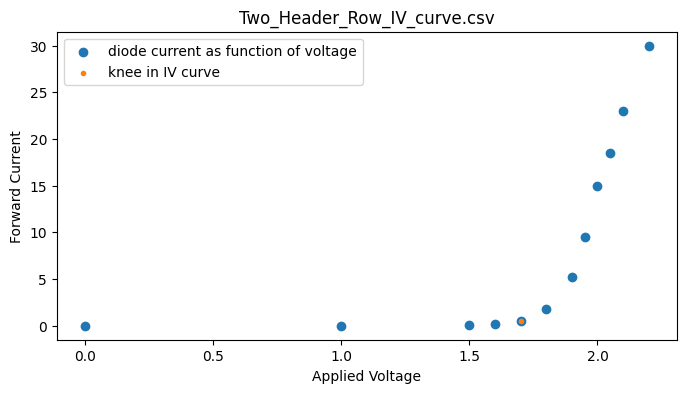

In [120]:
import matplotlib.pyplot as plt
plt.figure(figsize = (8, 4))
plt.scatter(diode_voltage, diode_current, marker = 'o',  label = "diode current as function of voltage" ) 
# this is plot current along horizontal (x) axis and voltage along vertical (y) axis
plt.scatter(diode_voltage[4], diode_current[4], marker = '.', label = "knee in IV curve")
# Add titles and labels
plt.title("Two_Header_Row_IV_curve.csv")
plt.xlabel("Applied Voltage")
plt.ylabel("Forward Current")
plt.legend(loc = "best") 

plt.show()